# 06 - Application: Zoopla Scrape + Model Inference

This notebook loads the trained model, scrapes Zoopla listings for a UK postcode, downloads listing photos, and predicts whether each image looks beach-front.

In [41]:
import json
import os
import re
import shutil
import sys
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from urllib.parse import parse_qs, quote, urlencode, urljoin, urlparse, urlunparse

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from PIL import Image


In [35]:
path = os.getcwd()
path = os.path.abspath(os.path.join(path, "..", "data"))
DATA_DIR = Path(path)
PROJECT_ROOT = DATA_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

MODELS_DIR = DATA_DIR.parent / "models"
MODEL_PATH = MODELS_DIR / "beach_predictor.joblib"
LIVE_DIR = DATA_DIR / "live"
LIVE_DIR.mkdir(parents=True, exist_ok=True)
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}. Run 05_model.ipynb first.")

from src.image_features import ImageFeatureConfig, extract_feature_frame
from src.model_bundle import predict_with_bundle, unpack_model_bundle

model_bundle = joblib.load(MODEL_PATH)
model_info = unpack_model_bundle(model_bundle)
feature_config = ImageFeatureConfig(**model_info["image_config"])
print(f"Loaded model bundle: {MODEL_PATH}")
print(f"Live image temp folder: {LIVE_DIR}")


Loaded model: /Users/marcel/Documents/github/property-near-the-beach-predictor/models/beach_predictor.joblib
Live image temp folder: /Users/marcel/Documents/github/property-near-the-beach-predictor/data/live


## Static UK postcode list

In [36]:
POSTCODES_UK = [
    "NE1",
    "SW1A",
    "M1",
    "B1",
    "LS1",
    "EH1",
    "CF10",
    "BT1",
]

POSTCODES_UK

['NE1', 'SW1A', 'M1', 'B1', 'LS1', 'EH1', 'CF10', 'BT1']

## Feature extraction (same shape as training/app)

113 features: RGB means/stds, HSV means, RGB histograms, and hue buckets.

In [37]:
FEATURE_COLS = model_info["feature_columns"]


## Zoopla scraping helpers

In [42]:
HEADERS = {
    "accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8",
    "accept-language": "en-GB,en-US;q=0.9,en;q=0.8",
    "cache-control": "no-cache",
    "pragma": "no-cache",
    "upgrade-insecure-requests": "1",
    "user-agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36"
    ),
}
PLAYWRIGHT_TIMEOUT_MS = 30000


def ensure_playwright():
    try:
        from playwright.sync_api import sync_playwright
        return sync_playwright
    except ImportError as exc:
        raise ImportError(
            "Playwright is required for this notebook. Install it with `pip install playwright` "
            "and run `playwright install chromium`."
        ) from exc


sync_playwright = ensure_playwright()


def zoopla_search_url(postcode: str) -> str:
    pc = postcode.upper().strip()
    return f"https://www.zoopla.co.uk/for-sale/property/{pc.lower()}/?q={quote(pc)}&search_source=home"


def _decoded_html_variants(html: str) -> list[str]:
    variants = [html]

    unescaped_slashes = html.replace("\\/", "/")
    if unescaped_slashes != html:
        variants.append(unescaped_slashes)

    try:
        unicode_decoded = bytes(unescaped_slashes, "utf-8").decode("unicode_escape")
        variants.append(unicode_decoded)
    except Exception:
        pass

    return variants


def _run_in_playwright_thread(fn, *args):
    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(fn, *args)
        return future.result()


def _fetch_rendered_html_sync(url: str) -> str:
    with sync_playwright() as p:
        browser = p.chromium.launch(headless=True)
        context = browser.new_context(
            user_agent=HEADERS["user-agent"],
            locale="en-GB",
            extra_http_headers={k: v for k, v in HEADERS.items() if k != "user-agent"},
        )
        page = context.new_page()
        page.goto(url, wait_until="domcontentloaded", timeout=PLAYWRIGHT_TIMEOUT_MS)
        page.wait_for_timeout(5000)
        html = page.content()
        browser.close()
        return html


def fetch_rendered_html(url: str) -> str:
    return _run_in_playwright_thread(_fetch_rendered_html_sync, url)


def _fetch_binary_with_playwright_sync(url: str) -> bytes:
    with sync_playwright() as p:
        browser = p.chromium.launch(headless=True)
        context = browser.new_context(
            user_agent=HEADERS["user-agent"],
            locale="en-GB",
            extra_http_headers={k: v for k, v in HEADERS.items() if k != "user-agent"},
        )
        response = context.request.get(url, headers=HEADERS, timeout=PLAYWRIGHT_TIMEOUT_MS)
        if not response.ok:
            browser.close()
            raise RuntimeError(f"Playwright download failed: {response.status} for {url}")
        body = response.body()
        browser.close()
        return body


def fetch_binary_with_playwright(url: str) -> bytes:
    return _run_in_playwright_thread(_fetch_binary_with_playwright_sync, url)


def extract_listing_urls(search_html: str, max_listings: int = 5) -> list[str]:
    urls = []

    soup = BeautifulSoup(search_html, "html.parser")
    for a in soup.select('a[href*="/for-sale/details/"]'):
        href = a.get("href")
        if not href:
            continue
        if "/for-sale/details/contact/" in href:
            continue
        full = urljoin("https://www.zoopla.co.uk", href)
        if full not in urls:
            urls.append(full)

    for html_variant in _decoded_html_variants(search_html):
        rel_urls = re.findall(r"/for-sale/details/(\d+)/", html_variant)
        abs_urls = re.findall(r"https://www\.zoopla\.co\.uk/for-sale/details/(\d+)/", html_variant)

        for lid in rel_urls:
            full = f"https://www.zoopla.co.uk/for-sale/details/{lid}/"
            if full not in urls:
                urls.append(full)

        for lid in abs_urls:
            full = f"https://www.zoopla.co.uk/for-sale/details/{lid}/"
            if full not in urls:
                urls.append(full)

    return urls[:max_listings]


def _set_query_param(url: str, key: str, value: str) -> str:
    parsed = urlparse(url)
    q = parse_qs(parsed.query)
    q[key] = [value]
    new_query = urlencode(q, doseq=True)
    return urlunparse((parsed.scheme, parsed.netloc, parsed.path, parsed.params, new_query, parsed.fragment))


def extract_next_page_url(search_html: str, current_url: str, current_page: int) -> str | None:
    soup = BeautifulSoup(search_html, "html.parser")

    next_link = soup.select_one('a[rel="next"]')
    if next_link and next_link.get("href"):
        return urljoin("https://www.zoopla.co.uk", next_link.get("href"))

    for sel in ["a[aria-label*='Next']", "a[title*='Next']", "a[data-testid*='next']"]:
        candidate = soup.select_one(sel)
        if candidate and candidate.get("href"):
            return urljoin("https://www.zoopla.co.uk", candidate.get("href"))

    # Fallback to a predictable page-number query param used by Zoopla searches.
    return _set_query_param(current_url, "pn", str(current_page + 1))


def collect_listing_urls_across_pages(start_url: str, max_pages: int = 5, max_listings: int = 25) -> tuple[list[str], int]:
    all_listing_urls = []
    seen_listing_urls = set()
    seen_page_urls = set()

    current_url = start_url
    pages_scanned = 0

    for page_number in range(1, max_pages + 1):
        if current_url in seen_page_urls:
            break
        seen_page_urls.add(current_url)

        search_html = fetch_rendered_html(current_url)
        pages_scanned += 1

        page_listing_urls = extract_listing_urls(search_html, max_listings=max_listings)
        for listing_url in page_listing_urls:
            if listing_url in seen_listing_urls:
                continue
            seen_listing_urls.add(listing_url)
            all_listing_urls.append(listing_url)
            if len(all_listing_urls) >= max_listings:
                return all_listing_urls[:max_listings], pages_scanned

        next_url = extract_next_page_url(search_html, current_url=current_url, current_page=page_number)
        if not next_url:
            break
        current_url = next_url

    return all_listing_urls[:max_listings], pages_scanned


def extract_image_urls(listing_html: str, max_images: int = 8) -> list[str]:
    candidates = []

    candidates.extend(re.findall(r"https://[^\"' ]+\.(?:jpe?g|png|webp)", listing_html, flags=re.IGNORECASE))

    soup = BeautifulSoup(listing_html, "html.parser")
    for img in soup.find_all("img"):
        for attr in ("src", "data-src", "srcset"):
            val = img.get(attr)
            if not val:
                continue
            if attr == "srcset":
                parts = [p.strip().split(" ")[0] for p in val.split(",")]
                candidates.extend(parts)
            else:
                candidates.append(val)

    for html_variant in _decoded_html_variants(listing_html):
        candidates.extend(re.findall(r"https://[^\"' ]+\.(?:jpe?g|png|webp)", html_variant, flags=re.IGNORECASE))

    clean = []
    seen = set()
    for u in candidates:
        if not isinstance(u, str):
            continue
        if not u.startswith("http"):
            continue
        if not re.search(r"\.(jpe?g|png|webp)(?:$|\?)", u, flags=re.IGNORECASE):
            continue
        if u in seen:
            continue
        seen.add(u)
        clean.append(u)

    return clean[:max_images]


def extract_property_details(listing_html: str, listing_url: str) -> dict:
    soup = BeautifulSoup(listing_html, "html.parser")

    title = None
    price = None
    address = None

    og_title = soup.find("meta", attrs={"property": "og:title"})
    if og_title and og_title.get("content"):
        title = og_title.get("content").strip()

    h1 = soup.find("h1")
    if h1 and h1.get_text(strip=True):
        title = title or h1.get_text(" ", strip=True)

    for sel in ["[data-testid='price']", "[data-testid='listing-price']", ".ui-pricing__main-price"]:
        node = soup.select_one(sel)
        if node and node.get_text(strip=True):
            price = node.get_text(" ", strip=True)
            break

    if not price:
        m_price = re.search(r"£\s?[\d,]+", soup.get_text(" ", strip=True))
        if m_price:
            price = m_price.group(0)

    for sel in ["[data-testid='address-label']", "[data-testid='address']", "h1 + p"]:
        node = soup.select_one(sel)
        if node and node.get_text(strip=True):
            address = node.get_text(" ", strip=True)
            break

    listing_id_match = re.search(r"/for-sale/details/(\d+)/", listing_url)
    listing_id = listing_id_match.group(1) if listing_id_match else re.sub(r"\W+", "_", listing_url)[-24:]

    return {
        "listing_id": listing_id,
        "title": title or "Unknown title",
        "price": price or "Unknown price",
        "address": address or "Unknown address",
        "listing_url": listing_url,
    }


def download_images_to_folder(image_urls: list[str], target_dir: Path, max_images: int = 8) -> list[Path]:
    target_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []
    for idx, u in enumerate(image_urls[:max_images], start=1):
        try:
            image_bytes = fetch_binary_with_playwright(u)

            ext = ".jpg"
            if ".png" in u.lower():
                ext = ".png"
            elif ".webp" in u.lower():
                ext = ".webp"

            file_path = target_dir / f"img_{idx:02d}{ext}"
            with open(file_path, "wb") as f:
                f.write(image_bytes)
            saved_paths.append(file_path)
        except Exception:
            continue

    return saved_paths


def fetch_listing_payload(listing_url: str, max_images: int = 8) -> dict:
    listing_html = fetch_rendered_html(listing_url)
    details = extract_property_details(listing_html, listing_url)
    image_urls = extract_image_urls(listing_html, max_images=max_images)

    property_live_dir = LIVE_DIR / details["listing_id"]
    image_paths = download_images_to_folder(image_urls, property_live_dir, max_images=max_images)

    return {
        "details": details,
        "image_paths": image_paths,
        "property_live_dir": property_live_dir,
    }

## Predict listing images

In [43]:
def predict_image(img: Image.Image, model_bundle) -> tuple[int, float]:
    X = extract_feature_frame([img], config=feature_config, feature_columns=FEATURE_COLS)
    pred, p_beach = predict_with_bundle(model_bundle, X)
    return int(pred[0]), float(p_beach[0])


def analyse_postcode_with_log(
    postcode: str,
    max_pages: int = 5,
    max_listings: int = 25,
    max_images_per_listing: int = 6,
):
    search_url = zoopla_search_url(postcode)
    print(f"Search URL: {search_url}")

    listing_urls, pages_scanned = collect_listing_urls_across_pages(
        start_url=search_url,
        max_pages=max_pages,
        max_listings=max_listings,
    )
    print(f"Pages scanned: {pages_scanned}")
    print(f"Listings discovered: {len(listing_urls)}")

    if not listing_urls:
        print("No listing URLs found. Zoopla may be blocking scraping or page structure changed.")
        return [], pd.DataFrame()

    running = {
        "pages_scanned": pages_scanned,
        "properties_scraped": 0,
        "images_pulled": 0,
        "beach_properties": 0,
    }

    all_results = []
    run_log = []

    for idx, listing_url in enumerate(listing_urls, start=1):
        payload = fetch_listing_payload(listing_url, max_images=max_images_per_listing)
        details = payload["details"]
        image_paths = payload["image_paths"]
        property_live_dir = payload["property_live_dir"]

        rows = []
        for image_idx, image_path in enumerate(image_paths, start=1):
            try:
                img = Image.open(image_path).convert("RGB")
            except Exception:
                continue

            pred, p_beach = predict_image(img, model_bundle)
            label = "BEACH" if pred == 1 else "NOT_BEACH"
            rows.append({
                "index": image_idx,
                "image": img.copy(),
                "prediction": pred,
                "label": label,
                "p_beach": p_beach,
                "image_file": str(image_path),
            })
            img.close()

        is_beach_property = any(row["prediction"] == 1 for row in rows)

        running["properties_scraped"] += 1
        running["images_pulled"] += len(image_paths)
        if is_beach_property:
            running["beach_properties"] += 1

        run_log.append({
            "step": idx,
            "pages_scanned": running["pages_scanned"],
            "listing_id": details["listing_id"],
            "properties_scraped": running["properties_scraped"],
            "images_pulled": running["images_pulled"],
            "beach_properties": running["beach_properties"],
            "image_count_this_property": len(image_paths),
            "is_beach_property": is_beach_property,
            "listing_url": details["listing_url"],
        })

        print(
            f"[{idx}/{len(listing_urls)}] pages={running['pages_scanned']} "
            f"scraped={running['properties_scraped']} images={running['images_pulled']} "
            f"beach_properties={running['beach_properties']} -> {details['listing_id']}"
        )

        all_results.append({
            "details": details,
            "rows": rows,
            "is_beach_property": is_beach_property,
        })

        shutil.rmtree(property_live_dir, ignore_errors=True)

    return all_results, pd.DataFrame(run_log)


## Run on Zoopla (example: NE1)

This notebook now uses Playwright to render Zoopla pages before scraping. If Cell 9 fails to import Playwright, install it with `pip install playwright` and then run `playwright install chromium`.

Search URL: https://www.zoopla.co.uk/for-sale/property/ne1/?q=NE1&search_source=home
Pages scanned: 1
Listings discovered: 25
[1/25] pages=1 scraped=1 images=8 beach_properties=0 -> 73590320
[2/25] pages=1 scraped=2 images=16 beach_properties=0 -> 73573771
[3/25] pages=1 scraped=3 images=24 beach_properties=0 -> 73523294
[4/25] pages=1 scraped=4 images=32 beach_properties=1 -> 73520215
[5/25] pages=1 scraped=5 images=40 beach_properties=2 -> 73500215
[6/25] pages=1 scraped=6 images=48 beach_properties=2 -> 60266995
[7/25] pages=1 scraped=7 images=56 beach_properties=3 -> 62652411
[8/25] pages=1 scraped=8 images=64 beach_properties=3 -> 63462424
[9/25] pages=1 scraped=9 images=72 beach_properties=3 -> 64523914
[10/25] pages=1 scraped=10 images=80 beach_properties=3 -> 65584790
[11/25] pages=1 scraped=11 images=88 beach_properties=3 -> 65584802
[12/25] pages=1 scraped=12 images=96 beach_properties=4 -> 65584815
[13/25] pages=1 scraped=13 images=104 beach_properties=5 -> 67634739
[14/25] 

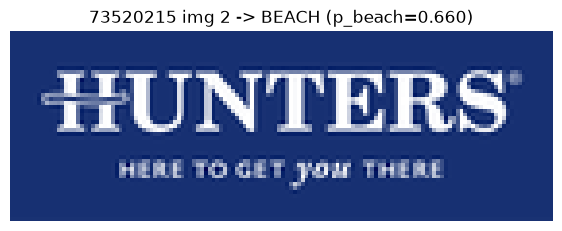


BEACH PROPERTY FOUND
Title:   Grey Street, Newcastle Upon Tyne NE1, 1 bed flat for sale, £120,000 - Zoopla
Price:   £120,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/73500215/


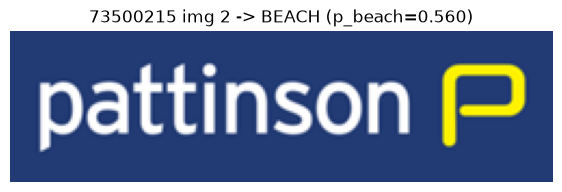


BEACH PROPERTY FOUND
Title:   Love Lane, Newcastle Upon Tyne NE1, 1 bed flat for sale, £125,000 - Zoopla
Price:   £125,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/62652411/


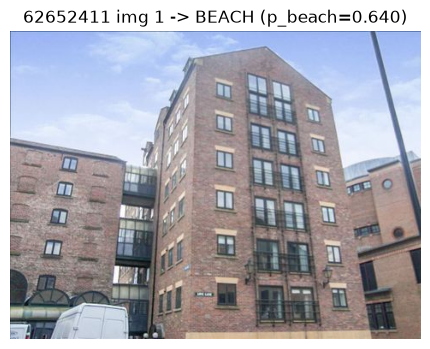

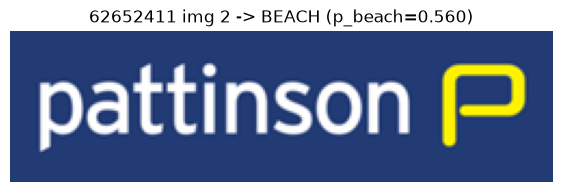


BEACH PROPERTY FOUND
Title:   St Anns Quay, Quayside NE1, 1 bed flat for sale, £100,000 - Zoopla
Price:   £100,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/65584815/


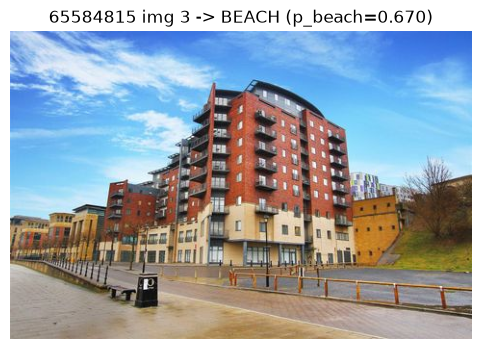

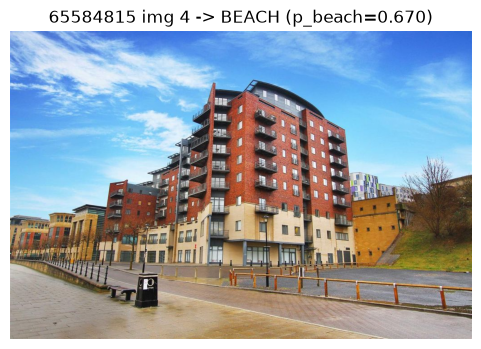


BEACH PROPERTY FOUND
Title:   St. James Gate, Newcastle Upon Tyne NE1, 2 bed flat for sale, £135,000 - Zoopla
Price:   £135,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/67634739/


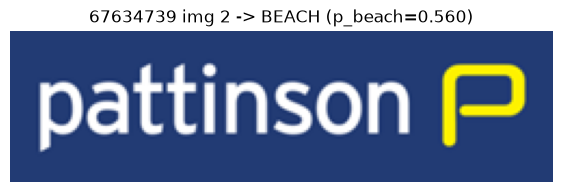


BEACH PROPERTY FOUND
Title:   Citygate, Bath Lane, Newcastle Upon Tyne, Tyne And Wear NE1, 2 bed flat for sale, £165,000 - Zoopla
Price:   £165,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/67640394/


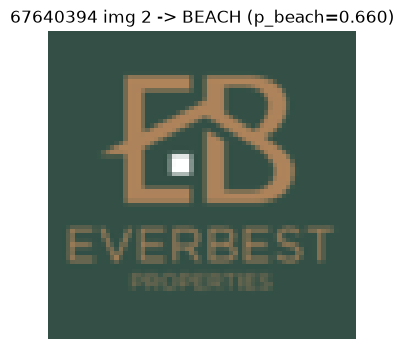


BEACH PROPERTY FOUND
Title:   Amen Corner, Newcastle Upon Tyne NE1, 1 bed flat for sale, £111,000 - Zoopla
Price:   £111,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/69016907/


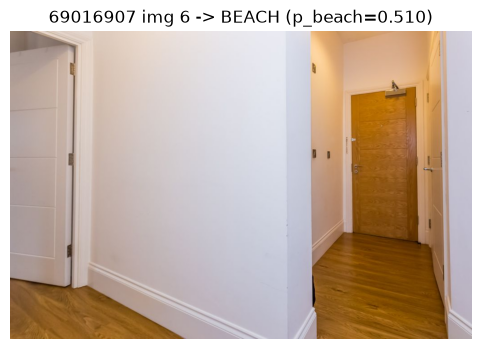

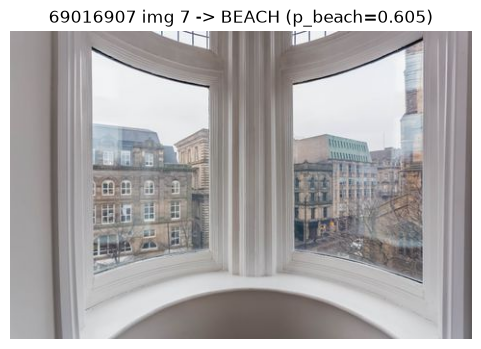

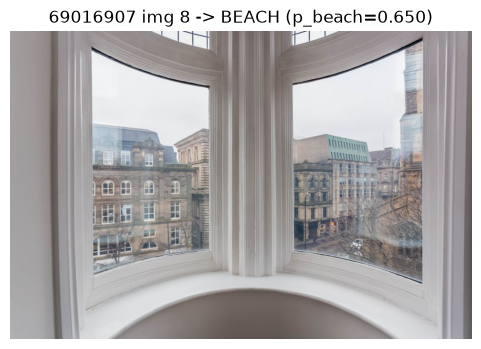


BEACH PROPERTY FOUND
Title:   The Chare, Newcastle Upon Tyne, Tyne And Wear NE1, 2 bed flat for sale, £125,000 - Zoopla
Price:   £125,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/69018537/


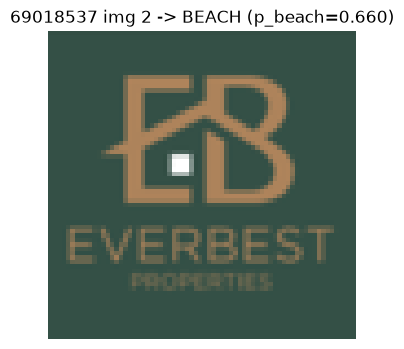


BEACH PROPERTY FOUND
Title:   St. James Gate, Newcastle Upon Tyne NE1, 2 bed flat for sale, £210,000 - Zoopla
Price:   £210,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/69381069/


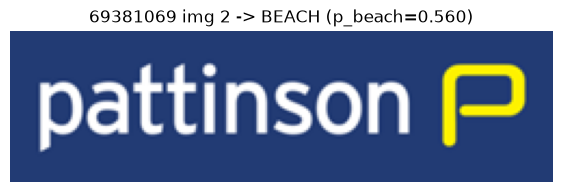


BEACH PROPERTY FOUND
Title:   Fecitygate, Bath Lane, Newcastle Upon Tyne, Tyne And Wear NE1, 2 bed flat for sale, £165,000 - Zoopla
Price:   £165,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/69613710/


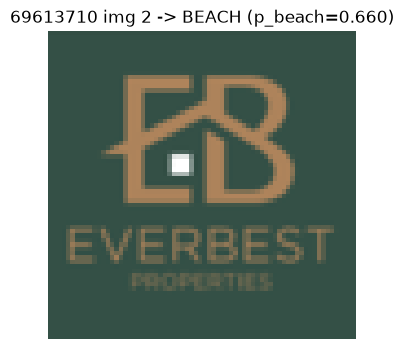


BEACH PROPERTY FOUND
Title:   Egwaterloo House, Thornton Street, Newcastle Upon Tyne, Tyne And Wear NE1, 2 bed flat for sale, £145,000 - Zoopla
Price:   £145,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/70205088/


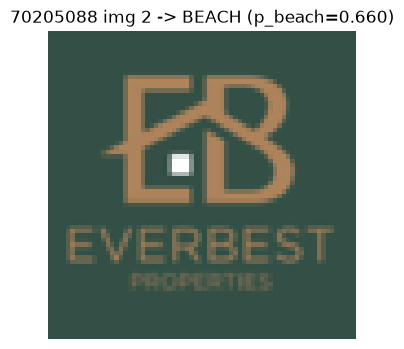


BEACH PROPERTY FOUND
Title:   Mllime Square City Road, Newcastle Upon Tyne, Tyne And Wear NE1, 2 bed flat for sale, £148,000 - Zoopla
Price:   £148,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/70281984/


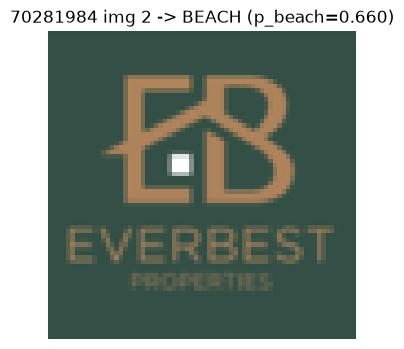


BEACH PROPERTY FOUND
Title:   Manor Chare, Newcastle Upon Tyne, Tyne And Wear NE1, 2 bed flat for sale, £180,000 - Zoopla
Price:   £180,000
Address: Unknown address
Link:    https://www.zoopla.co.uk/for-sale/details/70434746/


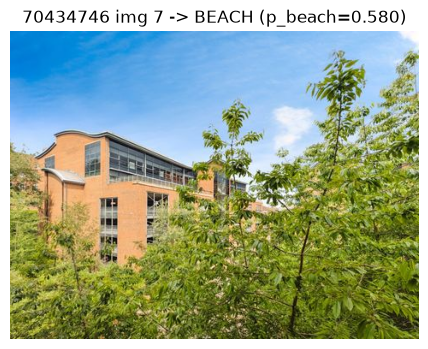

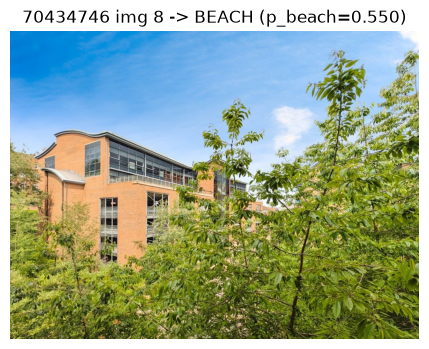

,postcode,listing_id,title,price,address,listing_url,image_index,label,p_beach
0,NE1,73520215,"Milk Market, Newcastle Upon Tyne NE1, 2 bed fl...","£200,000",Unknown address,https://www.zoopla.co.uk/for-sale/details/7352...,2,BEACH,0.660
1,NE1,73500215,"Grey Street, Newcastle Upon Tyne NE1, 1 bed fl...","£120,000",Unknown address,https://www.zoopla.co.uk/for-sale/details/7350...,2,BEACH,0.560
2,NE1,62652411,"Love Lane, Newcastle Upon Tyne NE1, 1 bed flat...","£125,000",Unknown address,https://www.zoopla.co.uk/for-sale/details/6265...,1,BEACH,0.640
3,NE1,62652411,"Love Lane, Newcastle Upon Tyne NE1, 1 bed flat...","£125,000",Unknown address,https://www.zoopla.co.uk/for-sale/details/6265...,2,BEACH,0.560
4,NE1,65584815,"St Anns Quay, Quayside NE1, 1 bed flat for sal...","£100,000",Unknown address,https://www.zoopla.co.uk/for-sale/details/6558...,3,BEACH,0.670
5,NE1,65584815,"St Anns Quay, Quayside NE1, 1 bed flat for sal...","£100,000",Unknown address,https://www.zoopla.co.uk/for-sale/details/6558...,4,BEACH,0.670
6,NE1,67634739,"St. James Gate, Newcastle Upon Tyne NE1, 2 bed...","£135,000",Unknown address,https://www.zoopla.co.uk/for-sale/details/6763...,2,BEACH,0.560
7,NE1,67640394,"Citygate, Bath Lane, Newcastle Upon Tyne, Tyne...","£165,000",Unknown address,https://www.zoopla.co.uk/for-sale/details/6764...,2,BEACH,0.660
8,NE1,69016907,"Amen Corner, Newcastle Upon Tyne NE1, 1 bed fl...","£111,000",Unknown address,https://www.zoopla.co.uk/for-sale/details/6901...,6,BEACH,0.510
9,NE1,69016907,"Amen Corner, Newcastle Upon Tyne NE1, 1 bed fl...","£111,000",Unknown address,https://www.zoopla.co.uk/for-sale/details/6901...,7,BEACH,0.605


In [44]:
SELECTED_POSTCODE = "NE1"
# Choose from POSTCODES_UK or set any postcode string

application_results, running_log_df = analyse_postcode_with_log(
    postcode=SELECTED_POSTCODE,
    max_pages=5,
    max_listings=25,
    max_images_per_listing=8,
)

print()
print("Running log:")
running_log_df

beach_rows = []

for item in application_results:
    details = item["details"]
    rows = item["rows"]

    if not item["is_beach_property"]:
        continue

    print()
    print("BEACH PROPERTY FOUND")
    print(f"Title:   {details['title']}")
    print(f"Price:   {details['price']}")
    print(f"Address: {details['address']}")
    print(f"Link:    {details['listing_url']}")

    beach_images = [r for r in rows if r["prediction"] == 1]
    for r in beach_images:
        title = f"{details['listing_id']} img {r['index']} -> {r['label']}"
        if not np.isnan(r["p_beach"]):
            title += f" (p_beach={r['p_beach']:.3f})"

        plt.figure(figsize=(7, 4))
        plt.imshow(r["image"])
        plt.title(title)
        plt.axis("off")
        plt.show()

        beach_rows.append({
            "postcode": SELECTED_POSTCODE,
            "listing_id": details["listing_id"],
            "title": details["title"],
            "price": details["price"],
            "address": details["address"],
            "listing_url": details["listing_url"],
            "image_index": r["index"],
            "label": r["label"],
            "p_beach": r["p_beach"],
        })

pd.DataFrame(beach_rows)